# Lab 05: Simulations

Welcome to Lab 05. 

We will go over [iteration](https://www.inferentialthinking.com/chapters/09/2/Iteration.html) and [simulations](https://www.inferentialthinking.com/chapters/09/3/Simulation.html), as well as introduce the concept of [randomness](https://www.inferentialthinking.com/chapters/09/Randomness.html).

First, set up the tests and imports by running the cell below.

<div style="background-color:#f2d8b2; border-left:6px solid #b36a00; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>ℹ️ Appropriate collaboration and AI usage</b><br>
<span style="font-size:0.9em;">You are welcome to collaborate with other students on this lab, as long as each student writes their own solutions. Consult with your teacher and course syllabus for information and policies regarding appropriate use of AI tools and submission of late work.</span>
</div>

In [1]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# This line suppresses scientific notation
np.set_printoptions(suppress = True)

## 1. Nachos and Conditionals

One day, when you come home after a long week, you see a hot bowl of nachos waiting on the dining table! Let's say that whenever you take a nacho from the bowl, it will either have only **cheese**, only **salsa**, **both** cheese and salsa, or **neither** cheese nor salsa (a sad tortilla chip indeed). 

Let's try to simulate taking nachos from the bowl at random and determining your reaction using Python. You'll need to learn how to generate random outcomes from a list of possible outcomes, inspect the outcomes to determine the correct reaction, and then return the correct reaction.

### `np.random.choice`

`np.random.choice` picks one item at random from the given array. It is equally likely to pick any of the items. Run the cell below several times, and observe how the results change.

In [2]:
nachos = make_array('cheese', 'salsa', 'both', 'neither')
np.random.choice(nachos)

'salsa'

To repeat this process multiple times, pass in an int `n` as the second argument to return `n` different random choices. By default, `np.random.choice` samples **with replacement** and returns an *array* of items. 

Run the next cell to see an example of sampling with replacement 10 times from the `nachos` array.

In [3]:
np.random.choice(nachos, 10)

array(['both', 'both', 'both', 'neither', 'salsa', 'salsa', 'cheese',
       'neither', 'neither', 'both'],
      dtype='<U7')

### Comparisons

In Python, the boolean data type contains only two unique values:  `True` and `False`. Expressions containing comparison operators such as `<` (less than), `>` (greater than), and `==` (equal to) evaluate to Boolean values. A list of common comparison operators can be found below!

| Comparison | Operator | True Example | False Example |
| --- | --- | --- | ---|
| Less than | `<` | `2 < 3` | `2 < 2` |
| Greater than | `>` | `3 > 2` | `3 > 3` |
| Less than or equal | `<=` | `2 <= 2` | `3 <= 2` |
| Greater than or equal | `>=` | `3 >= 3` | `2 >= 3` |
| Equal | `==` | `3 == 3` | `3 == 2` |
| Not equal | `!=` | `3 != 2` | `2 != 2` |

Run the cell below to see an example of a comparison operator in action.

In [4]:
3 > 1 + 1

True

You can even assign the result of a comparison operation to a variable, just like you can assign the result of any other Python expression.

In [5]:
result = 10 / 2 == 5
result

True

Arrays are also compatible with comparison operators. When comparing a value to an array, the output will be an array of boolean values that resulted from a comparison with each corresponding element in the array.

Comparisons can be made on numerical values.

In [6]:
make_array(1, 5, 7, 8, 3, -1) > 3

array([False,  True,  True,  True, False, False], dtype=bool)

And they can also be made on other data types, such as strings.

In [7]:
nachos == 'salsa'

array([False,  True, False, False], dtype=bool)

To count the number of times a certain type of nacho is randomly chosen, we can use `np.count_nonzero`.

### `np.count_nonzero`

`np.count_nonzero` counts the number of non-zero values that appear in an array. When an array of boolean values is passed through the function, it will count the number of `True` values in the array. 

**Remember:** in Python, `True` is equivalent in value to 1 and `False` is equivalent to 0.

Run the next cell to see an example that uses `np.count_nonzero`.

In [8]:
np.count_nonzero(make_array(True, False, False, True, True))

3

### Question 1.1.

Assume we took ten nachos at random, and with the results assigned to the array called `ten_nachos` in the code cell below. **Compute the number of nachos with only cheese on them** using a comparison operator (e.g. `==`, `<`, ...) and the `np.count_nonzero` function demonstrated above.

In [9]:
ten_nachos = make_array('neither', 'cheese', 'both', 'both', 'cheese', 'salsa', 'both', 'neither', 'cheese', 'cheese')
number_cheese = np.count_nonzero(ten_nachos == 'cheese') # SOLUTION
number_cheese

4

In [10]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `number_cheese` is an integer
failure_message: ❌ `number_cheese` is not an integer. Make sure you're using the np.count_nonzero function.
""" # END TEST CONFIG

isinstance(number_cheese, (int, np.integer))

True

In [11]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `number_cheese` is between 0 and 10
failure_message: ❌ `number_cheese` is not between 0 and 10, but it must be since there are 10 nachos in the array.
""" # END TEST CONFIG

0 <= number_cheese <= 10

True

In [12]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.50
success_message: ✅ `number_cheese` is the correct value!
failure_message: ❌ `number_cheese` is not the correct value. Make sure you are spelling 'cheese' correctly
""" # END TEST CONFIG

number_cheese == 4

True

### Conditional Statements

A conditional statement is a multi-line statement that allows Python to choose from different code blocks to run based on the truth value of an expression.

Here is a function to serve as a basic example.

```python
def sign(x):
    if x > 0:
        return 'Positive'
    else:
        return 'Negative'
```

If the input `x` is greater than `0`, the `sign` function returns the string `'Positive'`. Otherwise, it returns the string `'Negative'`.

If you wanted to test multiple conditions at once, use the following general format.

```python
if <if expression>:
    <if body>
elif <elif expression 0>:
    <elif body 0>
elif <elif expression 1>:
    <elif body 1>
...
else:
    <else body>
```


Each `if` and `elif` expression is evaluated and considered in order, starting at the top. As soon as a true value is found, the corresponding body is executed, and the rest of the conditional statement is skipped. If none of the `if` or `elif` expressions are true, then the `else` body is executed. 

For more examples and explanation, refer to the section on conditional statements [here](https://inferentialthinking.com/chapters/09/1/Conditional_Statements.html).

### Question 1.2.

Suppose you want to make sure that you have enough nachos with cheese on them.

Complete the following conditional statement so that `say_please` is assigned a value based on the number of nachos with cheese in `ten_nachos`. If the number of nachos with cheese is less than `5`, assign the string `'More please'` to `say_please`, otherwise assign the string `'Perfect!'`.

**Hint:** You should use `number_cheese` from earlier in this assignment, or, recompute the number of nachos with cheese in the array `ten_nachos`. You should not directly reassign the variable `say_please` with the correct value.


In [13]:
""" # BEGIN PROMPT
if ...:
    say_please = 'More please'
...
    ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
if number_cheese < 5:
    say_please = 'More please'
else:
    say_please = 'Perfect'
# END SOLUTION
say_please

'More please'

### Question 1.3.

Write a function called `nacho_reaction` that can be provided a nacho type (as a string) and returns a reaction (as a string) based on the type of nacho passed in as an argument. Use the table below to match the nacho type to the appropriate reaction.

| Nacho Type | Reaction |
|------------|----------|
| cheese     | Cheesy!  |
| salsa      | Spicy!   |
| both       | Wow!     |
| neither    | Meh.     |


For example:

```python
nacho_reaction('cheese')
```

Would return the string `'Cheesy!'`.

**Hint:** If you're failing the test, double check the spelling of your reactions.


In [14]:
""" # BEGIN PROMPT
def nacho_reaction(nacho):
    if nacho == "cheese":
        return ...
    ... :
        ...
    ... :
        ...
    ... :
        ...
"""; # END PROMPT

# BEGIN SOLUTION NO PROMPT
def nacho_reaction(nacho):
    if nacho == 'cheese':
        return 'Cheesy!'
    elif nacho == 'salsa':
        return 'Spicy!'
    elif nacho == 'both':
        return 'Wow!'
    else:
        return 'Meh.'
# END SOLUTION
spicy_nacho = nacho_reaction('salsa')
spicy_nacho

'Spicy!'

In [15]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.0
success_message: ✅ The `nacho_reaction` function returns strings
failure_message: ❌ The `nacho_reaction` function is not returning a string. Are you using print instead of return?
""" # END TEST CONFIG

type(nacho_reaction('salsa')) == str

True

In [16]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `nacho_reaction('salsa')` function returns the correct string
failure_message: ❌ The `nacho_reaction('salsa')` function is not returning the correct string. Check your spelling!
""" # END TEST CONFIG

nacho_reaction('salsa')

'Spicy!'

In [17]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `nacho_reaction('cheese')` function returns the correct string
failure_message: ❌ The `nacho_reaction('cheese')` function is not returning the correct string. Check your spelling!
""" # END TEST CONFIG

nacho_reaction('cheese')

'Cheesy!'

In [18]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `nacho_reaction('both')` function returns the correct string
failure_message: ❌ The `nacho_reaction('both')` function is not returning the correct string. Check your spelling!
""" # END TEST CONFIG

nacho_reaction('both')

'Wow!'

In [19]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `nacho_reaction('neither')` function returns the correct string
failure_message: ❌ The `nacho_reaction('neither')` function is not returning the correct string. Check your spelling!
""" # END TEST CONFIG

nacho_reaction('neither')

'Meh.'

### Question 1.4.

Create a Table named `ten_nachos_reactions` that consists of the nachos in the array `ten_nachos` in a column named `Nachos` as well as the reactions for each of those nachos in a column named `Reactions`.

To get you started, the code below will create a Table named `ten_nachos_tbl` that contains the array `ten_nachos` in a column labeled `Nachos`. You can take as many steps as you need to create the final table, but as an added challenge you can attempt to do it in a single line of code.

**Hint:** Use the `apply` method on the `ten_nachos_tbl` Table to create the array of reactions. Then, construct the final Table. Here's a link to the textbook [Chapter 8, Section 1: Applying a Function to a Column](https://www.inferentialthinking.com/chapters/08/1/Applying_a_Function_to_a_Column.html) if you need a refresher:  


In [20]:
ten_nachos_tbl = Table().with_column('Nachos', ten_nachos)
""" # BEGIN PROMPT
...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
ten_nachos_reactions = ten_nachos_tbl.with_column('Reactions', ten_nachos_tbl.apply(nacho_reaction, 'Nachos'))
# END SOLUTION
ten_nachos_reactions

Nachos,Reactions
neither,Meh.
cheese,Cheesy!
both,Wow!
both,Wow!
cheese,Cheesy!
salsa,Spicy!
both,Wow!
neither,Meh.
cheese,Cheesy!
cheese,Cheesy!


In [21]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `ten_nachos_reactions` is a Table object
failure_message: ❌ `ten_nachos_reactions` is not a Table. Did you only create the array of reactions?
""" # END TEST CONFIG

type(ten_nachos_reactions) == Table

True

In [22]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `ten_nachos_reactions` Table has the correct column labels
failure_message: ❌ The `ten_nachos_reactions` Table does not have the correct column labels, or they are in the incorrect order
""" # END TEST CONFIG

ten_nachos_reactions.labels == ('Nachos', 'Reactions')

True

In [23]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `ten_nachos_reactions` Table has the correct number of rows
failure_message: ❌ The `ten_nachos_reactions` Table does not have the correct number of rows
""" # END TEST CONFIG

ten_nachos_reactions.num_rows == 10

True

In [24]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.50
success_message: ✅ The `ten_nachos_reactions` Table has the correct reaction for each nacho
failure_message: ❌ The `ten_nachos_reactions` Table has one or more incorrect reaction results
""" # END TEST CONFIG

np.array_equal(ten_nachos_reactions.column('Reactions'), make_array('Meh.', 'Cheesy!', 'Wow!', 'Wow!', 'Cheesy!', 'Spicy!', 'Wow!', 'Meh.', 'Cheesy!', 'Cheesy!'))

True

### Question 1.5.

Compute the number of 'Wow!' reactions for the nachos in the `ten_nachos_reactions` Table. You should not manually count the number of reactions, so your code must reference the Table `ten_nachos_reactions` at least once.

**Hint:** There are a few ways to do this! Try seeing if you can use a comparison statement on an array to help out.

In [25]:
number_wow_reactions = np.count_nonzero(ten_nachos_reactions.column('Reactions') == 'Wow!') # SOLUTION
number_wow_reactions

3

In [26]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `number_wow_reactions` is an integer
failure_message: ❌ `number_wow_reactions` is not an integer
""" # END TEST CONFIG

isinstance(number_wow_reactions, (int, np.integer))

True

In [27]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `number_wow_reactions` is between 0 and 10
failure_message: ❌ `number_wow_reactions` is not between 0 and 10, but it must be since there are 10 nachos in the array.
""" # END TEST CONFIG

0 <= number_wow_reactions <= 10

True

In [28]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.50
success_message: ✅ `number_wow_reactions` is the correct value
failure_message: ❌ `number_wow_reactions` is not the correct value
""" # END TEST CONFIG

number_wow_reactions == 3

True

## 2. Simulations and For Loops
In Python, a `for` statement can perform a similar task multiple times. This repetitive process is known as **iteration**. In this course, iteration is most often seen as a `for` loop used to run simulations that involve randomness. However, that's not the only use for iteration in programming. This section will show you a few different ways to use iteration.

### Iterate over a collection
In general, a `for` loop is used to perform a block of code once for each value in a collection. For instance, the code below will print out all of the colors of the rainbow.

In [29]:
rainbow = make_array("red", "orange", "yellow", "green", "blue", "indigo", "violet")

for color in rainbow:
    print(color)

red
orange
yellow
green
blue
indigo
violet


We can see that the indented part of the `for` loop, known as the body, is executed once for each item in the array `rainbow`. The name `color` is assigned to the next value in `rainbow` at the start of each iteration. Note that the name `color` is arbitrary; we could easily have named it something else in the `for` loop definition. The important thing is that you stay consistent throughout the `for` loop.

In [30]:
for another_name in rainbow:
    print(another_name)

red
orange
yellow
green
blue
indigo
violet


However, in general it is a best practice for variable names to be somewhat descriptive about the values they hold.

### Question 2.1.

In the following cell, we've loaded the text of the novel _Pride and Prejudice_ by Jane Austen, split it into individual words, and stored these words in an array `p_and_p_words`. Use a `for` loop to load each word in the array `p_and_p_words` into the iterating variable (the one that you choose the name for) one at a time, and check if the current word is longer than 5 letters, and keep a running total of how many words are longer than 5 letters. When the loop completes, the variable `longer_than_five`, which is initially assigned the value `0`, should contain an integer that represents the number of words in _Pride and Prejudice_ that are more than 5 letters long.

**Hint:** You can find the number of letters in a word/string with the `len` function. You can reference the code cell below for an example:

In [31]:
my_word = 'hello'
len(my_word)

5

In [32]:
austen_string = open('Austen_PrideAndPrejudice.txt', encoding='utf-8').read()
p_and_p_words = np.array(austen_string.split())
""" # BEGIN PROMPT
longer_than_five = 0

# a for loop would be useful here
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
longer_than_five = 0

for word in p_and_p_words:
    if len(word) > 5:
        longer_than_five = longer_than_five + 1
# END SOLUTION
longer_than_five

35453

In [33]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `longer_than_five` is an integer
failure_message: ❌ `longer_than_five` is not an integer
""" # END TEST CONFIG

isinstance(longer_than_five, (int, np.integer))

True

In [34]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
failure_message: ❌ The value of `longer_than_five` suggests that you included words with 5 letters
success_message: ✅ `longer_than_five` counts only words longer than five letters
""" # END TEST CONFIG

longer_than_five !=48032

True

In [35]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `longer_than_five` is the correct value
failure_message: ❌ `longer_than_five` is an incorrect value
""" # END TEST CONFIG

longer_than_five == 35453

True

You should notice it didn't take very long to go through every word in the entire novel! This is a great example of how working with computers can speed up very routine simple tasks, like counting.

### Question 2.2.

Do you think the words in _Pride and Prejudice_ tend to be the same length, or different lengths? You could try to estimate how likely words are to have different lengths through choosing two words at random from the book, and seeing if they have the same length. Doing this just one time might not be insightful, but if you were to do this many times it could be helpful.

Complete a simulation with 10,000 trials, by writing a `for` loop to pick two words uniformly at random (with replacement) from _Pride and Prejudice_ and determine if the words have different lengths. When the simulation is completed, the variable `num_different` should be equal to the number of times that the two words selected in the simulations were different in length. Since there is randomness involved, your answer will likely be different from a classmate's, and will change each time you run the cell.

**Hint 1:** Recall the function used earlier to sample at random with replacement from an array.

**Hint 2:** Remember that `!=` checks for non-equality between two items.

In [36]:
""" # BEGIN PROMPT
trials = 10000
num_different = ...

for ... in ...:
    ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
trials = 10000
num_different = 0

for i in np.arange(trials):
    words = np.random.choice(p_and_p_words, 2)
    if len(words.item(0)) != len(words.item(1)):
        num_different = num_different + 1
# END SOLUTION
num_different

8607

In [37]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `num_different` is an integer
failure_message: ❌ `num_different` is not an integer
""" # END TEST CONFIG

isinstance(num_different, (int, np.integer))

True

In [38]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ Your value of `num_different` is in an expected range of values for this book
failure_message: ❌ Your value of `num_different` is not within an expected range of values for this book. Make sure you are choosing two words at random, and are checking that they are NOT equal in length.
""" # END TEST CONFIG

8100 <= num_different <= 9100

True

Before moving on to the next question, inspect the value you computed for `num_different`. How would you describe what this value means in context of the simulation you wrote? Discuss your interpretation with a classmate or teacher.

### Question 2.3.

Allie is playing a simplified version of darts. Her dartboard contains ten equal-sized zones with point values from 1 to 10. Write a simulation to determine her total score after 1000 dart tosses, assuming that each dart is equally likely to hit each region on the board. 

Note that while you _could_ write a `for` loop to complete this simulation, you don't need to. Remember that `np.random.choice(...)` can select multiple values from the same array if you provide a second argument that is an integer. Attempt to use `np.random.choice` in part of your solution after defining an array that contains all the possible outcomes of throwing a single dart. 

Since there is randomness involved, your answer will likely be different from a classmate's, and will change each time you run the cell.

In [39]:
""" # BEGIN PROMPT
possible_point_values = ...
num_tosses = 1000
simulated_tosses = ...
total_score = ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
possible_point_values = np.arange(1, 11)
num_tosses = 1000
simulated_tosses = np.random.choice(possible_point_values, num_tosses)
total_score = np.sum(simulated_tosses)
# END SOLUTION
total_score

5479

In [40]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `total_score` is an integer
failure_message: ❌ `total_score` is not an integer
""" # END TEST CONFIG

isinstance(total_score, (int, np.integer))

True

In [41]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ Your value of `total_score` is in an expected range of values for this game
failure_message: ❌ Your value of `total_score` is not within an expected range of values for this game. Are you totaling up the score from all of the throws?
""" # END TEST CONFIG

5000 <= total_score <= 6000

True

## 3. Sampling Basketball Data

We will now introduce the topic of sampling, which we’ll be discussing in more depth in upcoming classes. We’ll guide you through this code, but if you wish to read more about different kinds of samples before attempting this question, you can check out [section 10 of the textbook](https://www.inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html).

The data used in this section will contain salary data and other statistics for basketball players from the 2022-2023 NBA season. This data was collected from the following sports analytic sites: [Basketball Reference](http://www.basketball-reference.com) and [HoopsHype](https://hoopshype.com/salaries/players/2022-2023/).

Run the cell below to load player and salary data that we will use for our sampling. 

In [42]:
player_data = Table().read_table("player_data_2022.csv")
salary_data = Table().read_table("salary_data_2022.csv").set_format('Salary', CurrencyFormatter)

### `player_data`

The `player_data` Table contains statistics for each player for the 2022-2023 season. Run the cell below to inspect a few rows of the Table.

In [43]:
player_data

Player,Position,Age,Team,Games,Minutes,3P,2P,FT,Rebounds,Assists,Steals,Blocks,Turnovers,Fouls,Points
Jayson Tatum,SF,24,BOS,74,2732,240,487,531,649,342,78,51,213,160,2225
Joel Embiid,C,28,PHI,66,2284,66,662,661,670,274,66,112,226,205,2183
Luka Doncic,PG,23,DAL,66,2391,185,534,515,569,529,90,33,236,166,2138
Shai Gilgeous-Alexander,PG,24,OKC,68,2416,58,646,669,329,371,112,65,192,192,2135
Giannis Antetokounmpo,PF,28,MIL,63,2024,47,660,498,742,359,52,51,246,197,1959
Anthony Edwards,SG,21,MIN,79,2842,213,494,319,458,350,125,58,259,186,1946
Julius Randle,PF,28,NYK,77,2737,218,440,402,767,316,49,21,216,233,1936
Donovan Mitchell,SG,26,CLE,68,2432,245,434,319,289,301,99,27,180,168,1922
Trae Young,PG,24,ATL,73,2541,154,443,566,217,741,80,9,300,104,1914
Zach LaVine,SG,27,CHI,77,2768,204,469,363,345,327,69,18,194,159,1913


### `salary_data`

The `salary_data` Table contains salary information for each player for the 2022-2023 season. The column labeled `Salary` is an integer, but is formatted as a currency to make it a bit easier to read. 

Run the cell below to inspect a few rows of the Table.

In [44]:
salary_data

Player,Salary
Stephen Curry,"$48,070,014"
John Wall,"$47,345,760"
Russell Westbrook,"$47,080,179"
LeBron James,"$44,474,988"
Kevin Durant,"$44,119,845"
Bradley Beal,"$43,279,250"
Kawhi Leonard,"$42,492,492"
Paul George,"$42,492,492"
Giannis Antetokounmpo,"$42,492,492"
Damian Lillard,"$42,492,492"


### Question 3.1.

Use the `.join` method to create a Table that contains the combined information from both Tables. Assign this combined Table to `full_data`.

In [45]:
full_data = salary_data.join("Player", player_data, "Player") # SOLUTION
full_data

Player,Salary,Position,Age,Team,Games,Minutes,3P,2P,FT,Rebounds,Assists,Steals,Blocks,Turnovers,Fouls,Points
AJ Green,"$508,891",SG,23,MIL,35,345,44,9,4,45,22,6,0,9,31,154
AJ Griffin,"$3,536,160",SF,19,ATL,72,1401,101,147,42,153,73,42,12,42,87,639
AJ Lawson,"$371,432",SG,22,TOT,15,108,10,12,2,21,2,2,0,3,11,56
Aaron Gordon,"$20,690,909",PF,27,DEN,68,2055,60,369,191,446,203,54,51,98,129,1109
Aaron Holiday,"$1,968,175",PG,26,ATL,63,845,36,56,27,74,89,37,12,36,79,247
Aaron Nesmith,"$3,804,360",SF,23,IND,73,1816,115,137,119,277,98,55,34,75,235,738
Aaron Wiggins,"$1,563,518",SG,24,OKC,70,1297,48,138,59,210,80,39,15,55,110,479
Admiral Schofield,"$877,940",PF,25,ORL,37,451,24,31,21,62,31,8,5,16,61,155
Al Horford,"$26,500,000",C,36,BOS,63,1922,145,83,15,390,189,30,61,37,121,616
Alec Burks,"$10,012,800",SG,31,DET,51,1122,99,101,153,158,114,38,8,58,98,652


In [46]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `full_data` is a Table object
failure_message: ❌ `full_data` is not a Table. Check that you used `.join()` properly
""" # END TEST CONFIG

type(full_data) == Table

True

In [47]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `full_data` has the correct number of rows
failure_message: ❌ `full_data` has an incorrect number of rows
""" # END TEST CONFIG

full_data.num_rows

536

In [48]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `full_data` has the correct number of columns
failure_message: ❌ `full_data` has an incorrect number of columns
""" # END TEST CONFIG

full_data.num_columns

17

In [49]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.50
success_message: ✅ `full_data` has the correct column labels
failure_message: ❌ `full_data` is missing one of 'Salary', 'Age', or 'Player' in the column labels
""" # END TEST CONFIG

'Salary' in full_data.labels and 'Age' in full_data.labels and 'Player' in full_data.labels

True

### Analysis from a sample

For 536 players, it's not so unreasonable to expect to use all of the data to conduct an analysis, but it is usually very difficult and/or expensive to have a set of data with each person from the population represented in it. Instead, information on only a subset of the population can be collected. This subset is called a sample.

If we want to make estimates about a certain numerical property (like the mean, median, standard deviation, etc) of the entire population, we may have to come up with these estimates based only on a smaller sample. Whether these estimates are useful or not often depends on how the sample was gathered. We have prepared some example sample datasets to see how they compare to the full NBA dataset. Later we'll ask you to create your own samples to see how they behave.

In this section, you'll create 3 different samples and investigate how the chosen method impacts the results:
* Convenience sample
* Small simple random sample
* Large simple random sample

### Helper Functions
To save typing and increase the clarity of your code, we will package the analysis code into a few functions that you can use. Some functions will be provided, and some you will need to write. These functions will be useful in the rest of the lab as we will repeatedly need to create histograms and collect summary statistics from sample data.

### `histograms`
The `histograms` function is defined below. It takes a Table that must contain columns named `Age` and `Salary` and draws a histogram for each one. It uses bin widths of 1 year for `Age` and $1,000,000 for `Salary`.

**Note:** This function ONLY takes in a table with these labels. It will not work if the Table provided as an input does not have these labels.

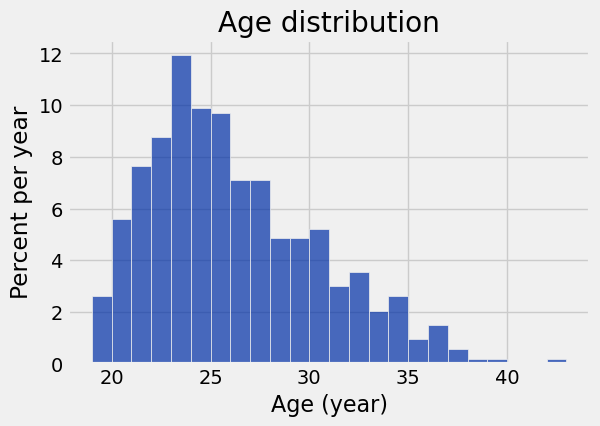

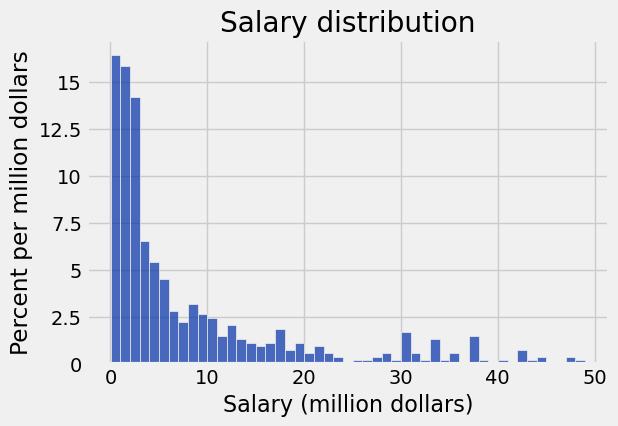

In [50]:
def histograms(t):
    ages = t.column('Age')
    salaries = t.column('Salary')/1000000
    t1 = t.drop('Salary').with_column('Salary', salaries)
    age_bins = np.arange(min(ages), max(ages) + 2, 1) 
    salary_bins = np.arange(min(salaries), max(salaries) + 1, 1)
    t1.hist('Age', bins=age_bins, unit='year')
    plt.title('Age distribution')
    t1.hist('Salary', bins=salary_bins, unit='million dollars')
    plt.title('Salary distribution') 
    
histograms(full_data)

### Question 3.2.

Define a function called `compute_statistics` that takes a table containing ages and salaries and returns a two-element `array` containing the average age and average salary of the players in the provided Table (in that order).

Then, call the function using the full set of data contained in the Table `full_data` to determine the mean age and salary from the whole population of NBA players.

**Note:** We wrote the solution using 3 lines in the body of the function, but you may be able to do it using more or fewer lines of code.

In [51]:
def compute_statistics(age_and_salary_data):
    age = age_and_salary_data.column("Age") # SOLUTION
    salary = age_and_salary_data.column("Salary") # SOLUTION
    return make_array(np.mean(age), np.mean(salary)) # SOLUTION

full_stats = compute_statistics(full_data)
full_stats

array([      25.70335821,  8237518.87686567])

In [52]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `compute_statistics` returns an array
failure_message: ❌ `compute_statistics` does not return an array. Did you return a value from the function? Did you use `make_array`?
""" # END TEST CONFIG

type(compute_statistics(full_data)) == np.ndarray

True

In [53]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.75
success_message: ✅ `compute_statistics` returns the correct averages for the population
failure_message: ❌ `compute_statistics` does not return the correct averages for the population. Are they in the correct order (age, salary)?
""" # END TEST CONFIG

np.allclose( compute_statistics(full_data), (25.70335821, 8237518.87686567))

True

### Convenience sample
One sampling methodology, **which is generally a bad idea**, is to choose players who are somehow convenient to sample.  For example, you might choose players from a team that plays in your city, since it's easier to survey them in person.  This is called, somewhat pejoratively, *convenience sampling*.

Suppose you were only able to survey *relatively new* players with ages less than 22 because the more experienced players didn't bother to answer your surveys about their salaries. Think about how that might impact the statistics about the sample compared to the full population of players.

### Question 3.3.

Assign `convenience_sample` to a subset of `full_data` that contains only the rows for players under the age of 22. This will mimic only being able to acquire a convenience sample based on player age.

In [54]:
convenience_sample = full_data.where("Age", are.below(22)) # SOLUTION
convenience_sample

Player,Salary,Position,Age,Team,Games,Minutes,3P,2P,FT,Rebounds,Assists,Steals,Blocks,Turnovers,Fouls,Points
AJ Griffin,"$3,536,160",SF,19,ATL,72,1401,101,147,42,153,73,42,12,42,87,639
Aleksej Pokusevski,"$3,261,480",PF,21,OKC,34,701,38,70,22,159,64,20,43,43,58,276
Alperen Sengun,"$3,375,360",C,20,HOU,75,2171,19,423,206,678,291,70,70,193,258,1109
Anthony Edwards,"$10,733,400",SG,21,MIN,79,2842,213,494,319,458,350,125,58,259,186,1946
BJ Boston,"$1,563,518",SF,21,LAC,22,248,12,39,29,30,20,9,0,12,21,143
Bennedict Mathurin,"$6,586,800",SG,20,IND,78,2222,100,313,376,318,116,48,13,152,162,1302
Blake Wesley,"$2,385,480",SG,19,SAS,37,669,20,49,26,81,99,25,5,65,67,184
Bryce McGowens,"$1,461,055",SG,20,CHO,46,787,26,54,60,93,54,15,6,43,48,246
Cade Cunningham,"$10,552,800",PG,21,DET,12,400,17,76,36,74,72,10,7,39,34,239
Caleb Houstan,"$2,000,000",SF,20,ORL,51,812,46,20,15,99,30,12,7,18,63,193


In [55]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `convenience_sample` has the correct number of rows
failure_message: ❌ `convenience_sample` does not have the correct number of rows. Check to make sure you did not include 22 year olds in the sample.
""" # END TEST CONFIG

convenience_sample.num_rows

85

In [56]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `convenience_sample` contains the correct player ages.
failure_message: ❌ `convenience_sample` does not contain the correct player ages.
""" # END TEST CONFIG

np.array_equal( convenience_sample.sort('Age').column('Age'), np.array([19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21] ))

True

In [57]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `convenience_sample` contains the correct player salaries.
failure_message: ❌ `convenience_sample` does not contain the correct player salaries.
""" # END TEST CONFIG

np.array_equal(convenience_sample.sort('Salary').column('Salary'), np.array([106288,   193027,   239822,   503041,   508891,   508891, 508891,   508891,   508891,   508891,   520589,   853241, 1017781,  1017781,  1017781,  1017781,  1017781,  1200000, 1461055,  1505966,  1563518,  1563518,  1563518,  1563518, 1575000,  1882621,  2000000,  2000000,  2109480,  2125200, 2138160,  2193960,  2210040,  2226000,  2239920,  2306520, 2372160,  2385480,  2408891,  2471160,  2573760,  2588640, 2681040,  2696400,  2792640,  2808600,  2898243,  2925600, 3046200,  3047640,  3191400,  3261480,  3359160,  3375360,3433320,  3536160,  3722040,  3740160,  4004280,  4124280, 4144320,  4341480,  4569840,  4591680,  4810320,  5063520, 5258280,  5508600,  5739840,  5837760,  6012960,  6287400, 6586800,  6922320,  7252200,  7644600,  7775400,  8478720, 8623920,  8882640,  9441840,  9603360, 10552800, 10733400, 11055120]))

True

### Question 3.4.

Assign `convenience_stats` to an array of the average age and average salary of your convenience sample, using the `compute_statistics` function.  Since these averages are computed from a sample from a larger population, they are called *sample averages*. 

In [58]:
convenience_stats = compute_statistics(convenience_sample) # SOLUTION
convenience_stats

array([      20.31764706,  3472346.67058824])

In [59]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `convenience_stats` contains the correct averages
failure_message: ❌ `convenience_stats` does not contain the correct averages. Confirm that you are passing the test for the previous question
""" # END TEST CONFIG

np.allclose(convenience_stats, (20.31764706,  3472346.67058824))

True

### Comparing Samples

Next, we'll compare the distributions of the convenience sample salaries with those in the full data salaries in a single histogram. An overlaid histogram makes it easier to compare two distributions to see how they are similar and different. The function `compare_salaries` below will create this overlaid histogram for you. You don't need to understand how it works, but you're welcome to see if you can figure it out if you're up for a challenge!

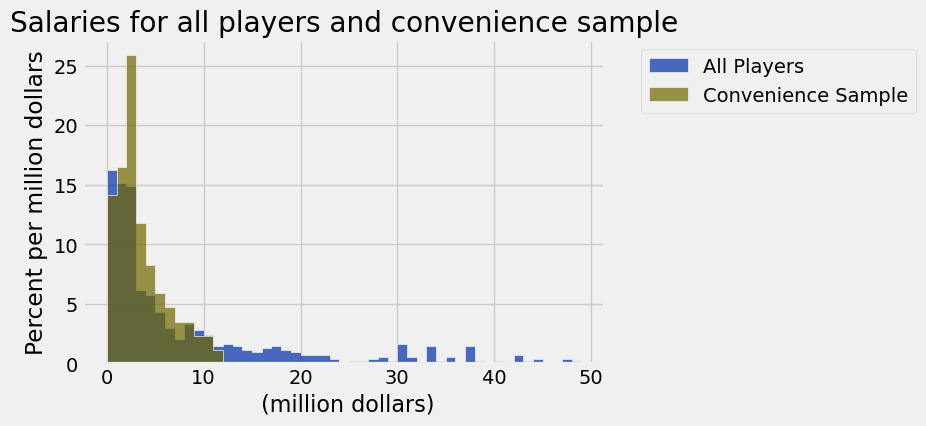

In [60]:
def compare_salaries(first, second, first_title, second_title):
    """Compare the salaries in two tables."""
    first_salary_in_millions = first.column('Salary')/1000000
    second_salary_in_millions = second.column('Salary')/1000000
    first_tbl_millions = first.drop('Salary').with_column('Salary', first_salary_in_millions)
    second_tbl_millions = second.drop('Salary').with_column('Salary', second_salary_in_millions)
    max_salary = max(np.append(first_tbl_millions.column('Salary'), second_tbl_millions.column('Salary')))
    bins = np.arange(0, max_salary+1, 1)
    first_binned = first_tbl_millions.bin('Salary', bins=bins).relabeled(1, first_title)
    second_binned = second_tbl_millions.bin('Salary', bins=bins).relabeled(1, second_title)
    first_binned.join('bin', second_binned).hist(bin_column='bin', unit='million dollars')
    plt.title('Salaries for all players and convenience sample')

compare_salaries(full_data, convenience_sample, 'All Players', 'Convenience Sample')

### Question 3.5.

Does the convenience sample give us an accurate picture of the salary of the full population? Explain why or why not using evidence from the histograms and summary statistics generated for the convenience sample and the full population to back up your claims. Offer an explanation as to why the sample does or does not represent the larger population in context of the data. Meaning, why would it make sense for younger players to have the same salaries as the overall population of players, or why would it make sense that younger players do not have the same salaries as the overall population of players.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** No, the convenience sample does not give us an accurate picture of the salary of the full population of NBA players in 2022-2023. We would not expect it to, because it is biased towards players younger than 22. Younger players are risky and unproven, so they won't command the top dollars until they prove their worth.

### Simple random sampling
A more justifiable approach is to sample uniformly at random from the players.  In a **simple random sample (SRS) without replacement**, we ensure that each player is selected at most once. Imagine writing down each player's name on a card, putting the cards in a box, and shuffling the box.  Then, pull out cards one by one and set them aside, stopping when the specified sample size is reached.

### Producing simple random samples
Sometimes, it’s useful to take random samples even when we have the data for the whole population. It helps us understand sampling accuracy.

### `sample`

The table method `sample` produces a random sample from the table. By default, it draws at random **with replacement** from the rows of a table. It takes in the sample size as its argument and returns a **table** with only the rows that were selected. 

Run the cell below to see an example call to `sample()` with a sample size of 5, with replacement. Because the sample will be based on a random process, you may or may not see the same player more than once due to the selection with replacement. You can try running the cell more than once, but with such a large data set (over 500 players) it's unlikely to see the same player more than once when only selecting 5.

In [61]:
salary_data.sample(5)

Player,Salary
Moussa Diabate,"$508,891"
Ron Harper Jr,"$508,891"
Jack White,"$508,891"
Cole Anthony,"$3,613,680"
Cameron Payne,"$6,000,000"


The optional argument `with_replacement=False` can be passed as an input to the `sample()` method to specify that the sample should be drawn without replacement. This will guarantee that the same player does not appear more than once in your sample.

Run the cell below to see an example call to `sample()` with a sample size of 5, without replacement.

In [62]:
salary_data.sample(5, with_replacement = False)

Player,Salary
Trent Forrest,"$508,891"
Dereon Seabron,"$511,816"
Markelle Fultz,"$16,500,000"
Lester Quinones,"$129,405"
Trae Young,"$37,096,500"


### Question 3.6.a

Produce a simple random sample of size 44 from `full_data` and save the sample to the Table named `my_small_srswor_data`. Create a histogram of the age and salary distributions using the `histograms` function, and compute the average age and salary using the `compute_statistics` function.

Due to the randomness of creating a sample, the averages and distributions will change each time the cell is run. Run the cell several times to see how the distributions and averages change from sample to sample.

array([      26.20454545,  8592137.11363636])

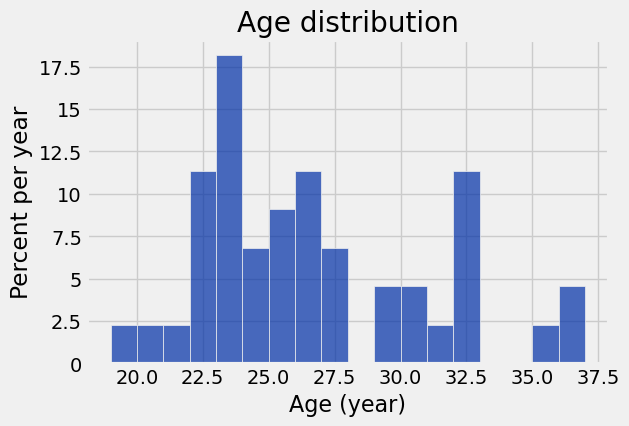

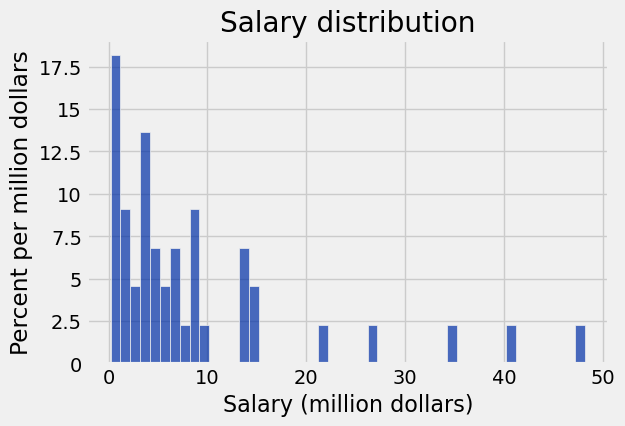

In [63]:
my_small_srswor_data = full_data.sample(44, with_replacement = False) # SOLUTION
histograms(my_small_srswor_data) # SOLUTION
my_small_stats = compute_statistics(my_small_srswor_data) # SOLUTION
my_small_stats

Run the cell below to see how the distribution of salaries in your most recent small simple random sample compares to the total population of players.

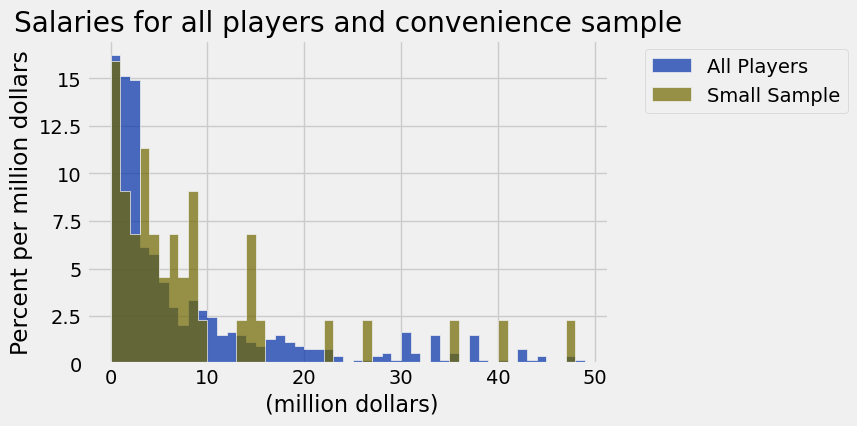

In [64]:
compare_salaries(full_data, my_small_srswor_data, 'All Players', 'Small Sample')

### Question 3.6.b

How well does a small simple random sample tend to approximate the total population? Write an explanation of your observations and use information from the histograms or summary statistics to back up your claims. You should consider how the average age and salary changed as you drew several different samples and describe which seemed to change more from sample to sample: the average age or the average salary. Why do you think that is, based on the ages and salaries in the dataset?

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** The average age tends to stay around the same value as there is a limited range of ages for NBA players, but the salary changes by a sizeable factor due to larger variability in salary.

### Question 3.7.

Using the same method as the previous question, analyze several simple random samples but this time of size 100 from `full_data`. 

Due to the randomness of creating a sample, the averages and distributions will change each time the cell is run. Run the cell several times to see how the distributions and averages change from sample to sample.

array([      25.45,  6468377.42])

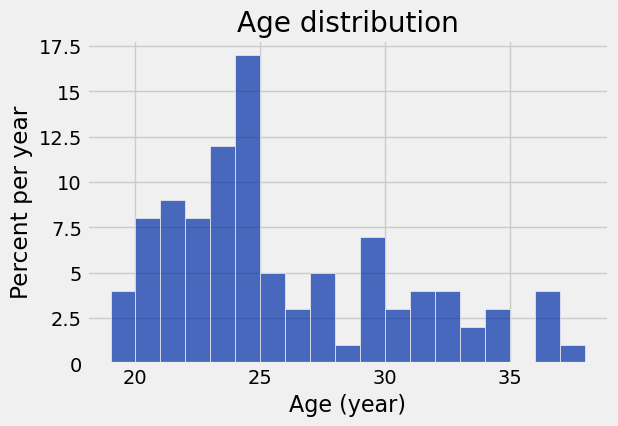

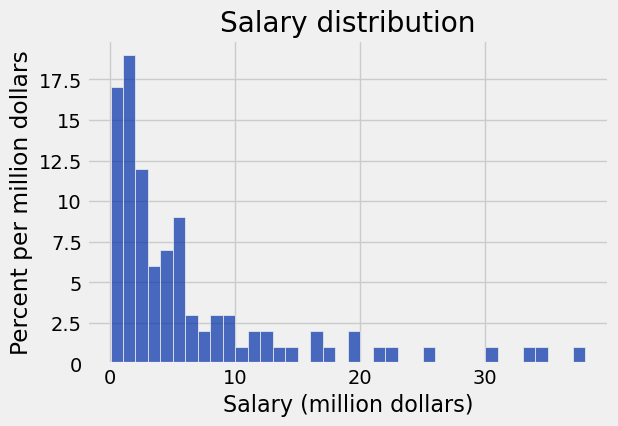

In [65]:
my_large_srswor_data = full_data.sample(100, with_replacement = False) # SOLUTION
histograms(my_large_srswor_data) # SOLUTION
my_large_stats = compute_statistics(my_large_srswor_data) # SOLUTION
my_large_stats

Run the cell below to see how the distribution of salaries in your most recent large simple random sample compares to the total population of players.

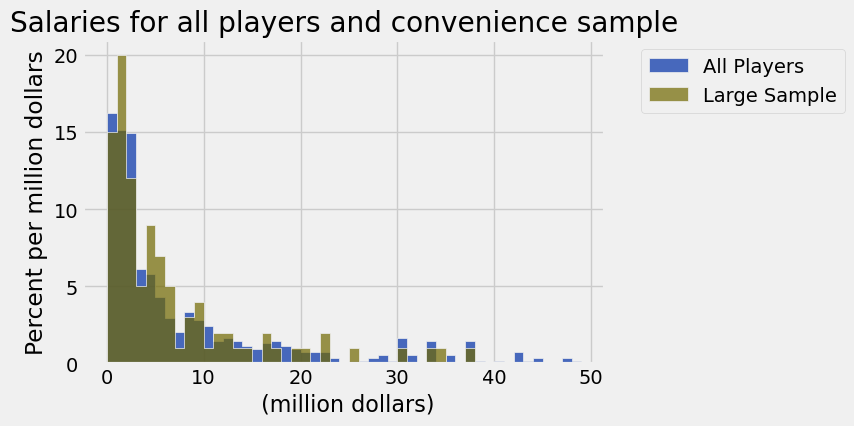

In [66]:
compare_salaries(full_data, my_large_srswor_data, 'All Players', 'Large Sample')

### Question 3.7.b

Does using samples of size 100 seem to do a better job at approximating the total population than samples of size 44? Your explanation should compare and contrast the histograms and summary statistics from the small and large sampling methods, and explain how one of them does a better job at accurately representing the total population.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** The average and histogram statistics seem to change less across samples of 100. They are closer to their true values, which is what we'd expect to see because we are sampling a larger subset of the population. The histogram and sample average for age seem closer to their true value or shape. We'd expect this because players' ages are less variable than their salaries.

# Submitting your work
You're done with this assignment! Assignments should be turned in using the following best practices:
1. Save your notebook.
2. Restart the kernel and run all cells up to this one.
3. Run the cell below with the code `grader.export(...)`. This will re-run all the tests. Make sure they are passing as you expect them to.
4. Download the file named `lab05_<date-time-stamp>.zip`, found in the explorer pane on the left side of the screen. **Note**: If clicking on the link in this notebook results in an error, try downloading the file from the file explorer panel on the left.
5. Upload `lab05_<date-time-stamp>.zip` to the corresponding assignment on Canvas.